In [2]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

# Resizing data to 256 , and random cropping 224X224 improves performance as Resnet and VGG Models are built with that expectation and trained such .
#As this is transfer learning that size and crop works best . 
#Random Horizontal Flip introduced for better training . Normalized data to Imagenet Mean and Standard Deviation
# Batch size 32 for Resnet models are they are faster and less complex and training time is manageable .
#Batch Size 64 for VGG19 as its more complex model with very high training time . 


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transformer = transforms.Compose([
transforms.Resize(256),
transforms.RandomCrop(224),
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

validation_transformer = transforms.Compose([
transforms.Resize(256),
transforms.CenterCrop(224),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

dataset_train = datasets.ImageFolder("dataset10/train", transform=train_transformer, allow_empty=True)
dataset_validation = datasets.ImageFolder("dataset10/val", transform=validation_transformer, allow_empty=True)

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_validation = DataLoader(dataset_validation, batch_size=64, shuffle=False)
print("Setup Complete")

cuda
Setup Complete


In [23]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model.features)
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = 10
#model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 512),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(512, num_classes),
)

TRAINING
Train Acc  86.416
Epoch 1/20, Loss: 0.9065059423446655
Val Acc  97.0
Train Acc  91.872
Epoch 2/20, Loss: 0.016486063599586487
Val Acc  95.4
Train Acc  92.272
Epoch 3/20, Loss: 0.07819215208292007
Val Acc  95.8
Train Acc  93.024
Epoch 4/20, Loss: 0.11667380481958389
Val Acc  97.0
Train Acc  93.12
Epoch 5/20, Loss: 0.1001705676317215
Val Acc  97.0
Train Acc  93.296
Epoch 6/20, Loss: 0.3037105202674866
Val Acc  97.0
Train Acc  93.8
Epoch 7/20, Loss: 0.4561809003353119
Val Acc  97.4
Train Acc  93.64
Epoch 8/20, Loss: 0.21768918633460999
Val Acc  96.6
Train Acc  94.168
Epoch 9/20, Loss: 0.2822498083114624
Val Acc  96.2
Train Acc  94.344
Epoch 10/20, Loss: 0.2476494312286377
Val Acc  96.8
Train Acc  94.408
Epoch 11/20, Loss: 0.10696589946746826
Val Acc  96.6
Train Acc  94.104
Epoch 12/20, Loss: 0.707312285900116
Val Acc  98.0
Train Acc  94.568
Epoch 13/20, Loss: 0.01704208180308342
Val Acc  97.6
Train Acc  94.208
Epoch 14/20, Loss: 0.0323723666369915
Val Acc  97.0
Train Acc  94.304


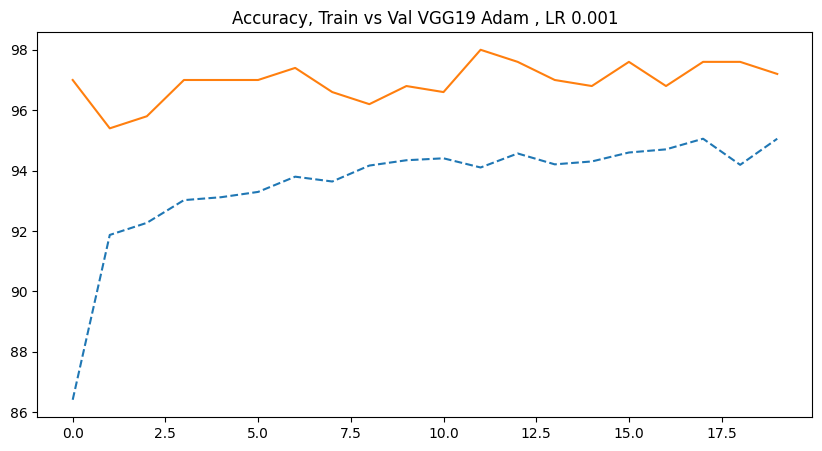

In [25]:

train_acc_list = []
val_acc_list = []

print("TRAINING")
epochs=20
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = 100 * correct / total
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = 100 *correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'VGG19_CNN_Adam.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val VGG19 Adam , LR 0.001")
plt.plot(train_acc_list, label='Train Acc VGG19 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc VGG19 CNN', linestyle='-')

In [32]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model.features)
# Freezing 1st 24 layers
for param in model.features.parameters():
    param.requires_grad = False
#Training remaining layers
#for param in model.features[29:].parameters():
#    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = 10
#model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 512),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(512, num_classes),
)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

TRAINING with Cosine LR Scheduler 
11064
12500
Train Acc  88.512
Epoch 1/20, Loss: 0.4217503070831299
488
500
Val Acc  97.6
11825
12500
Train Acc  94.6
Epoch 2/20, Loss: 0.12593762576580048
483
500
Val Acc  96.6
11910
12500
Train Acc  95.28
Epoch 3/20, Loss: 0.024511290714144707
488
500
Val Acc  97.6
11998
12500
Train Acc  95.984
Epoch 4/20, Loss: 0.07484017312526703
487
500
Val Acc  97.4
12042
12500
Train Acc  96.336
Epoch 5/20, Loss: 0.019956013187766075
490
500
Val Acc  98.0
12121
12500
Train Acc  96.968
Epoch 6/20, Loss: 0.06757833808660507
492
500
Val Acc  98.4
12127
12500
Train Acc  97.016
Epoch 7/20, Loss: 0.002379520097747445
493
500
Val Acc  98.6
12190
12500
Train Acc  97.52
Epoch 8/20, Loss: 0.009524708613753319
489
500
Val Acc  97.8
12223
12500
Train Acc  97.784
Epoch 9/20, Loss: 0.05144588276743889
489
500
Val Acc  97.8
12252
12500
Train Acc  98.016
Epoch 10/20, Loss: 0.2330954521894455
492
500
Val Acc  98.4
12277
12500
Train Acc  98.216
Epoch 11/20, Loss: 0.002783540403470

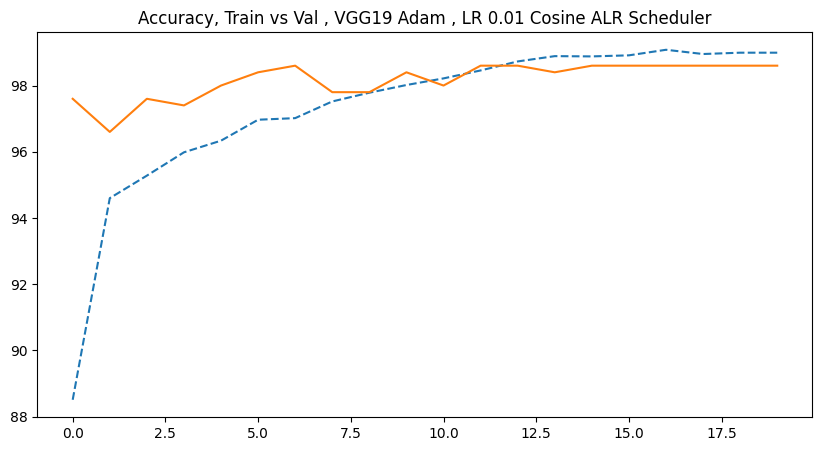

In [33]:

train_acc_list = []
val_acc_list = []

print("TRAINING with Cosine LR Scheduler ")
epochs=20
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = 100 * correct / total
  scheduler.step()  
  print(correct)
  print(total)  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = 100 * correct_val / total_val
        print( correct_val)
        print(total_val)
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'VGG19_CNN_ADAM_CosineALRScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , VGG19 Adam , LR 0.0001 Cosine ALR Scheduler")
plt.plot(train_acc_list, label='Train Acc VGG19 CNN Cosine LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc VGG19 CNN  Cosine LR Scheduler', linestyle='-')


In [34]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model.features)
# Freezing 1st 24 layers
for param in model.features.parameters():
    param.requires_grad = False
#Training remaining layers
#for param in model.features[29:].parameters():
#    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = 10
#model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 512),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(512, num_classes),
)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

TRAINING with Step LR Scheduler 
Train Acc  0.85888
Epoch 1/20, Loss: 0.4438405930995941
Val Acc  0.966
Train Acc  0.93952
Epoch 2/20, Loss: 0.45472127199172974
Val Acc  0.974
Train Acc  0.95168
Epoch 3/20, Loss: 0.12412615120410919
Val Acc  0.97
Train Acc  0.95568
Epoch 4/20, Loss: 0.2059636414051056
Val Acc  0.984
Train Acc  0.95968
Epoch 5/20, Loss: 0.12551353871822357
Val Acc  0.984
Train Acc  0.96352
Epoch 6/20, Loss: 0.0613451823592186
Val Acc  0.988
Train Acc  0.96232
Epoch 7/20, Loss: 0.08815066516399384
Val Acc  0.986
Train Acc  0.96416
Epoch 8/20, Loss: 0.054755885154008865
Val Acc  0.988
Train Acc  0.96488
Epoch 9/20, Loss: 0.16061170399188995
Val Acc  0.984
Train Acc  0.9636
Epoch 10/20, Loss: 0.008236333727836609
Val Acc  0.988
Train Acc  0.96544
Epoch 11/20, Loss: 0.08593512326478958
Val Acc  0.988
Train Acc  0.96432
Epoch 12/20, Loss: 0.09209339320659637
Val Acc  0.988
Train Acc  0.968
Epoch 13/20, Loss: 0.05481349676847458
Val Acc  0.988
Train Acc  0.96416
Epoch 14/20, 

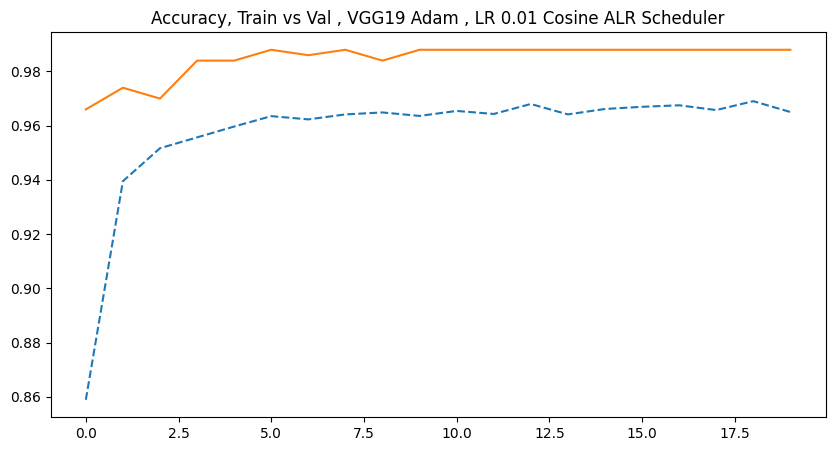

In [35]:

train_acc_list = []
val_acc_list = []

print("TRAINING with Step LR Scheduler ")
epochs=20
optimizer = optim.SGD(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'VGG19_CNN_SGD_CosineALRScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , VGG19 SGD , LR 0.01 Cosine ALR Scheduler")
plt.plot(train_acc_list, label='Train Acc VGG19 CNN Step LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc VGG19 CNN  Step LR Scheduler', linestyle='-')


In [41]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model.features)
# Freezing 1st 24 layers
for param in model.features.parameters():
    param.requires_grad = False
#Training remaining layers
#for param in model.features[29:].parameters():
#    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = 10
#model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 512),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(512, num_classes),
)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

TRAINING - ADAM, Weight Decay 1e-4 , lr 0.0001, Cosine ALR Scheduler
Train Acc  0.9052
Epoch 1/20, Loss: 0.07534575462341309
Val Acc  0.98
Train Acc  0.94104
Epoch 2/20, Loss: 0.0966944471001625
Val Acc  0.97
Train Acc  0.95232
Epoch 3/20, Loss: 0.13415321707725525
Val Acc  0.974
Train Acc  0.95864
Epoch 4/20, Loss: 0.014102660119533539
Val Acc  0.974
Train Acc  0.96384
Epoch 5/20, Loss: 0.04158895090222359
Val Acc  0.982
Train Acc  0.96768
Epoch 6/20, Loss: 0.17635682225227356
Val Acc  0.978
Train Acc  0.97176
Epoch 7/20, Loss: 0.11513756215572357
Val Acc  0.98
Train Acc  0.97592
Epoch 8/20, Loss: 0.018766339868307114
Val Acc  0.97
Train Acc  0.97728
Epoch 9/20, Loss: 0.14933782815933228
Val Acc  0.982
Train Acc  0.97952
Epoch 10/20, Loss: 0.09567569941282272
Val Acc  0.986
Train Acc  0.98032
Epoch 11/20, Loss: 0.0010745333274826407
Val Acc  0.976
Train Acc  0.9828
Epoch 12/20, Loss: 0.016141582280397415
Val Acc  0.978
Train Acc  0.98544
Epoch 13/20, Loss: 0.000566222530324012
Val Acc

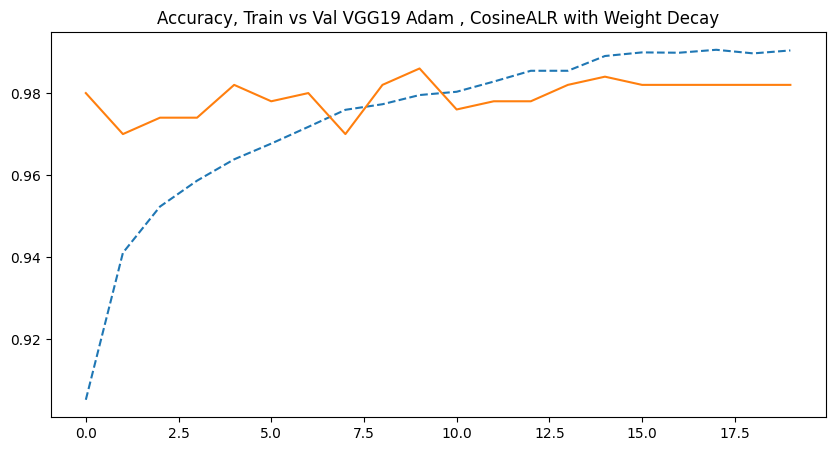

In [43]:

train_acc_list = []
val_acc_list = []

print("TRAINING - ADAM, Weight Decay 1e-4 , lr 0.0001, Cosine ALR Scheduler")
epochs=20
optimizer = optim.Adam(model.parameters(), lr=0.0001,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'VGG19_CNN_ADAM_WeightDecay.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val VGG19 Adam , CosineALR with Weight Decay")
plt.plot(train_acc_list, label='Train Acc VGG19 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc VGG19 CNN', linestyle='-')

In [3]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model.features)
# Freezing 1st 24 layers
for param in model.features.parameters():
    param.requires_grad = False
#Training remaining layers
#for param in model.features[29:].parameters():
#    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = 10
#model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 512),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(512, num_classes),
)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

TRAINING - SGD, Weight Decay 1e-4 , lr 0.01, Cosine ALR Scheduler
Train Acc  0.8604111671066315
Epoch 1/20, Loss: 0.09094911068677902
Val Acc  0.974
Train Acc  0.9363250939924807
Epoch 2/20, Loss: 0.2360677272081375
Val Acc  0.97
Train Acc  0.9496040316774658
Epoch 3/20, Loss: 0.12560269236564636
Val Acc  0.986
Train Acc  0.9564834813214943
Epoch 4/20, Loss: 0.08278931677341461
Val Acc  0.978
Train Acc  0.9576033917286617
Epoch 5/20, Loss: 0.008419356308877468
Val Acc  0.984
Train Acc  0.9633629309655227
Epoch 6/20, Loss: 0.017773602157831192
Val Acc  0.986
Train Acc  0.9659227261819054
Epoch 7/20, Loss: 0.1825011521577835
Val Acc  0.984
Train Acc  0.9644028477721782
Epoch 8/20, Loss: 0.05830412358045578
Val Acc  0.99
Train Acc  0.9663226941844653
Epoch 9/20, Loss: 0.06392937153577805
Val Acc  0.986
Train Acc  0.9672826173906087
Epoch 10/20, Loss: 0.14679987728595734
Val Acc  0.984
Train Acc  0.968642508599312
Epoch 11/20, Loss: 0.0601130947470665
Val Acc  0.986
Train Acc  0.9710423166

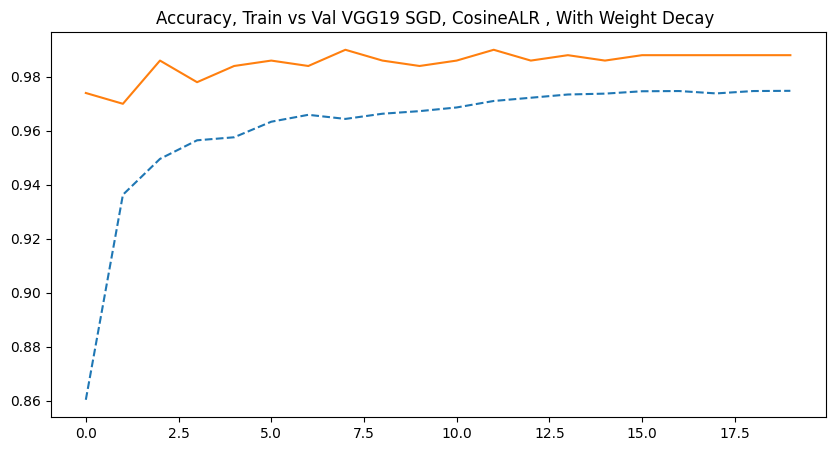

In [4]:

train_acc_list = []
val_acc_list = []

print("TRAINING - SGD, Weight Decay 1e-4 , lr 0.01, Cosine ALR Scheduler")
epochs=20
optimizer = optim.SGD(model.parameters(), lr=0.01,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'VGG19_CNN_SGD_WeightDecay.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val VGG19 SGD, CosineALR , With Weight Decay ")
plt.plot(train_acc_list, label='Train Acc VGG19 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc VGG19 CNN', linestyle='-')

In [5]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model.features)
# Freezing 1st 29 layers
for param in model.features[:29].parameters():
    param.requires_grad = False
#Training remaining layers
for param in model.features[29:].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = 10
#model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 512),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(512, num_classes),
)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

TRAINING with CNN Layers Unfrozen - ADAM, lr features 1e-5, lr classifier 1e-3 Cosine ALR Scheduler, 
Train Acc  0.92056
Epoch 1/10, Loss: 0.287394255399704
Val Acc  0.96
Train Acc  0.9404
Epoch 2/10, Loss: 0.01864052750170231
Val Acc  0.964
Train Acc  0.95616
Epoch 3/10, Loss: 0.0054410360753536224
Val Acc  0.97
Train Acc  0.96048
Epoch 4/10, Loss: 0.020215705037117004
Val Acc  0.968
Train Acc  0.96784
Epoch 5/10, Loss: 0.2112973928451538
Val Acc  0.966
Train Acc  0.97512
Epoch 6/10, Loss: 0.01967734843492508
Val Acc  0.972
Train Acc  0.97872
Epoch 7/10, Loss: 0.052180834114551544
Val Acc  0.984
Train Acc  0.98176
Epoch 8/10, Loss: 0.009713388048112392
Val Acc  0.98
Train Acc  0.98488
Epoch 9/10, Loss: 0.061815835535526276
Val Acc  0.982
Train Acc  0.98592
Epoch 10/10, Loss: 0.04999636113643646
Val Acc  0.984


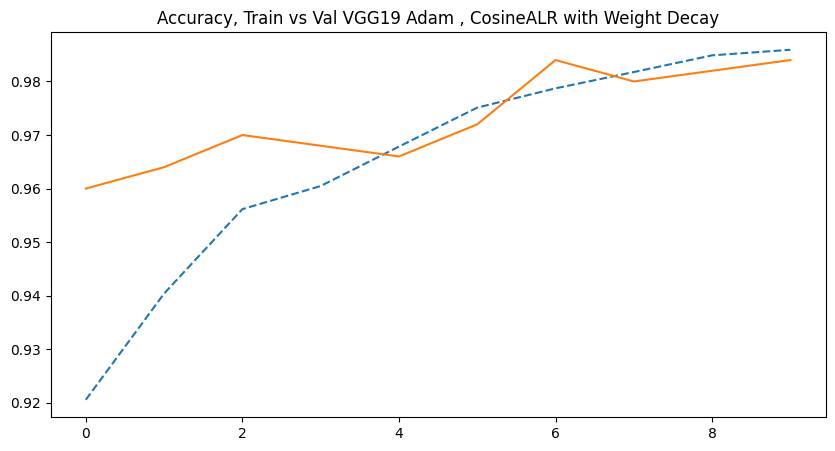

In [7]:

train_acc_list = []
val_acc_list = []

print("TRAINING with CNN Layers Unfrozen - ADAM, lr features 1e-5, lr classifier 1e-3 Cosine ALR Scheduler, ")
epochs=10

optimizer = optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])

#optimizer = optim.Adam(model.parameters(), lr=0.0001,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'VGG19_CNN_ADAM_UnfrozenCNNLayers.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val VGG19 Adam , CosineALR with Weight Decay")
plt.plot(train_acc_list, label='Train Acc VGG19 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc VGG19 CNN', linestyle='-')

In [10]:
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

print(model.features)
# Freezing 1st 24 layers
for param in model.features[:24].parameters():
    param.requires_grad = False
#Training remaining layers
for param in model.features[24:].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = 10
#model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 512),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(512, num_classes),
)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

TRAINING with CNN Layers Unfrozen - ADAM, lr features 1e-5, lr classifier 1e-3 Cosine ALR Scheduler, 
Train Acc  0.87816
Epoch 1/10, Loss: 0.09559415280818939
Val Acc  0.956
Train Acc  0.95032
Epoch 2/10, Loss: 0.26562634110450745
Val Acc  0.974
Train Acc  0.95792
Epoch 3/10, Loss: 0.039527617394924164
Val Acc  0.966
Train Acc  0.96776
Epoch 4/10, Loss: 0.08811786025762558
Val Acc  0.972
Train Acc  0.97392
Epoch 5/10, Loss: 0.0004443475918378681
Val Acc  0.974
Train Acc  0.98136
Epoch 6/10, Loss: 0.018933849409222603
Val Acc  0.978
Train Acc  0.98312
Epoch 7/10, Loss: 0.007073973771184683
Val Acc  0.98
Train Acc  0.9868
Epoch 8/10, Loss: 0.08548586070537567
Val Acc  0.978
Train Acc  0.9888
Epoch 9/10, Loss: 0.02905537746846676
Val Acc  0.982
Train Acc  0.99032
Epoch 10/10, Loss: 0.00045924022560939193
Val Acc  0.984


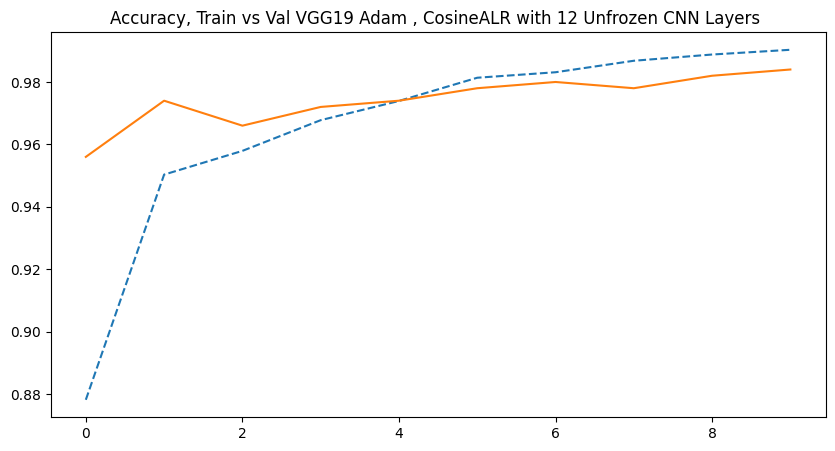

In [11]:

train_acc_list = []
val_acc_list = []

print("TRAINING with CNN Layers Unfrozen - ADAM, lr features 1e-5, lr classifier 1e-3 Cosine ALR Scheduler, ")
epochs=10

optimizer = optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])

#optimizer = optim.Adam(model.parameters(), lr=0.0001,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'VGG19_CNN_ADAM_12_UnfrozenCNNLayers.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val VGG19 Adam , CosineALR with 12 Unfrozen CNN Layers ")
plt.plot(train_acc_list, label='Train Acc VGG19 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc VGG19 CNN', linestyle='-')